Problem 1.

$$
U(x,y) = \frac{\epsilon}{2} \left(\left|\frac{x}{a}\right| + \left|\frac{y}{b}\right| \right)
$$

Relevant notes: Lecture 8

a) Homogeneity $k = 1$

$$
U(\alpha x, \alpha y) = \alpha U(x,y)
$$

<!-- So Euler's theorem says 
$$
U(x,y) = \frac{\partial U(x,y)}{\partial x} + \frac{\partial U(x,y)}{\partial y}
$$ -->

b) The total energy is $T+U = \mathcal{E}$, so we can use our degree of homogeneity $k=1$
$$
\def\E{\mathcal{E}}
\\  \langle T \rangle + \langle U \rangle = \E
\\ 2\langle T \rangle = \langle U \rangle
\\  \langle T \rangle = \frac{1 \E}{3}
\\  \langle U \rangle = \frac{2\E}{3}
$$



c) Ripping directly from Bunker's notebook:

| k | orbitsize    | period   | velocity | angularmomentum | energy $\E$ | action |
| --| ---          | ---      | ---      | ---             | ---    | ---    |
| k = 1 | $\alpha$ |$\sqrt{\alpha}$|$\sqrt{\alpha}$          |$\alpha^{3/2}$                 |$\alpha$        |$\alpha^{3/2} $       |

Using $\phi = \alpha$

Problem 2.

Mechanics of the previous problem.

a)
$$
L = T - U = \frac{1}{2} m \left(v_x^2 + v_y^2 \right) - \frac{\epsilon}{2} \left(\left|\frac{x}{a}\right| + \left|\frac{y}{b}\right| \right)
$$

b)
$$
    L(x, \dot x,y, \dot y) = L_x(x, \dot x) + L_y(y, \dot y)
\\  L_x(x, \dot x) = \frac{1}{2} m \dot x^2 - \frac{\epsilon}{2a} |x|
\\  L_y(y, \dot y) = \frac{1}{2} m \dot y^2 - \frac{\epsilon}{2b} |y|
$$

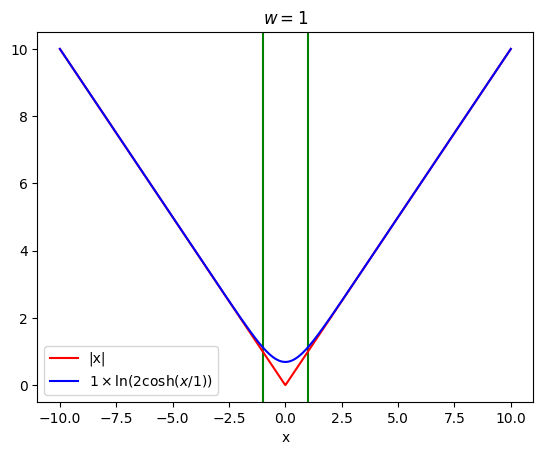

In [99]:
# c)

import matplotlib.pyplot as plt
import numpy as np

w = 1
x = np.linspace(-10*w,10*w, 1000)
plt.axvline(-w, color='green')
plt.axvline( w, color='green')
plt.plot(x, np.abs(x), color = 'red', label='|x|')
plt.plot(x, w*np.log(2*np.cosh(x/w)), color = 'blue', label=rf'${w}\times\ln(2\cosh(x/{w}))$')
plt.xlabel('x')
plt.legend()
plt.title(rf'$w={w}$');

In [100]:
# d) The EOMs are
import sympy as sp
from sympy.physics.mechanics import *
w, m, a, b, epsilon, t= sp.symbols('w m a b epsilon t', positive='True')
x, y = dynamicsymbols('x y')
dx, dy = dynamicsymbols('x y', 1)
ddy = dynamicsymbols('y', 2)

def analytic_abs(x, w):
    return w * sp.ln(2*sp.cosh(x/w))

T = 1/2 * m * (dx*dx + dy*dy)
U = epsilon / 2 * ( analytic_abs(x, w)/a + analytic_abs(y, w)/b )
L = T - U
display(sp.nsimplify(sp.simplify(L)))

LM = LagrangesMethod(L, [x, y])
for lhs in LM.form_lagranges_equations():
    EOM = sp.Eq(lhs, 0)
    display(sp.nsimplify(sp.simplify(EOM)))
    

(a*b*m*(Derivative(x(t), t)**2 + Derivative(y(t), t)**2) - epsilon*w*(a*log(2*cosh(y(t)/w)) + b*log(2*cosh(x(t)/w))))/(2*a*b)

Eq(m*Derivative(x(t), (t, 2)) + epsilon*tanh(x(t)/w)/(2*a), 0)

Eq(m*Derivative(y(t), (t, 2)) + epsilon*tanh(y(t)/w)/(2*b), 0)

Problem 3.

$$
U(x) = \frac{\epsilon}{2} \left(\left(\frac{x}{a}\right)^2 + \left(\frac{a}{x} \right)^2 \right)
$$

i) Turning points will depend on total energy.

$$
\def\E{\mathcal{E}}

\E = U(x)
$$

In [101]:
a, epsilon, E = sp.symbols('a epsilon E', positive=True)
x = sp.symbols('x')

U = epsilon/2 * ((x/a)**2 + (a/x)**2)
display(*sp.solve(sp.Eq(U, E), x))

-a*sqrt(E - sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

a*sqrt(E - sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

-a*sqrt(E + sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

a*sqrt(E + sqrt(E - epsilon)*sqrt(E + epsilon))/sqrt(epsilon)

That's double the number of solutions for $x$? Actually, this result makes sense since the potential is mirrored across the y-axis. The turning points are

$$
\def\E{\mathcal{E}}
x_{\pm} = \frac{a}{\sqrt\epsilon} \sqrt{\E \pm \sqrt{\E^2-\epsilon^2}},
$$
where $\E_{\min} = \epsilon$ is the ground state energy.

ii) Use period integral

$$
\def\E{\mathcal{E}}
    T(\E) = 2 \int_{x_-}^{x_+} \frac{dx}{v(x)}.
$$
Velocity comes from potential energy at a point
$$
    \E = T+U
\\  T = \E-U = \frac{1}{2} m v^2
\\  v(z) = \sqrt{\frac{2}{m} \left(\E-U(z)\right)}
\\  T(\E) = 2\int_{x_-}^{x_+} \frac{1}{\sqrt{\frac{2}{m} \left(\E-U(z)\right)}} dx
\\  = 2\sqrt{m \over 2} \int_{x_-}^{x_+} \frac{1}{\sqrt{\E - \frac{\epsilon}{2} \left(\frac{x}{a}\right)^2 - \frac{\epsilon}{2} \left(\frac{a}{x} \right)^2 }} dx
%\\  = \sqrt{m \over 2} \int_{x_-}^{x_+} \frac{1}{\sqrt{\E - \frac{\epsilon x^2}{2a^2} - \frac{\epsilon a^2}{2 x^2}}} dx
%\\  = \sqrt{m \over 2} \int_{x_-}^{x_+} \frac{1}{\sqrt{\E - \frac{\epsilon x^2}{2a^2} - \frac{\epsilon a^2}{2 x^2}}} dx
$$

I tried using $u = x/a$ and got nowhere, so let's see if we can get further with this

$$
    u=\frac{x^2}{a^2} 
\quad dx 
    = \frac{a}{2\sqrt{u}} du

\\  T(\E) 
    = 2\sqrt{m \over 2} \int_{u_-}^{u_+} 
    \frac{a}{2\sqrt{u}\sqrt{
        \E - \frac{\epsilon}{2}\left(u+u^{-1}\right)
        }} du

\\  = a\sqrt{m \over 2} \int_{u_-}^{u_+} 
    \frac{1}{\sqrt{
        u\E - \frac{\epsilon u^2}{2} + \frac{\epsilon}{2}
        }}du
$$
where 
$$u_\pm = \frac{x_{\pm}^2}{a^2}= \frac{\E \pm \sqrt{\E^2 - \epsilon^2}}{\epsilon}.$$


At this point, I had with the completing the square hint. I tried $Ax^2 + Bx+C = A\left(x+\frac{B}{2A}\right)^2 + \left(C - \frac{B^2}{4A}\right)$, and derived everything out and tried to use sympy but got nowhere. It was only when I looked up at $u_\pm$ that I recognized the form looks strangely similar to the quadratic equation, and remembered that you can just write a quadratic as a product of its roots.

$$
\sqrt{\E u - \frac{\epsilon}{2}u^2 + \frac{\epsilon}{2}} = \sqrt{\epsilon \over 2} \sqrt{-1 u^2 + \frac{2\E}{\epsilon}u + 1}
\\  u_{0\pm} = \frac{-b \pm \sqrt{b^2-4ac}}{2a}
\\[0.5em]
    a = -1 \quad b = \frac{2\E}{\epsilon} \quad c = 1
\\  u_{0\pm} = \frac{-\left( 2 \E \over \epsilon \right) \pm \sqrt{ \left( 2 \E \over \epsilon \right)^2-4(-1)}}{2(-1)}
             = \frac{ \left( 2 \E \over \epsilon \right) \pm \sqrt{4\left(   \E \over \epsilon \right)^2+4    }}{2}
\\           = \frac{\E \pm \sqrt{\E^2 - \epsilon^2}}{\epsilon} = u_{\pm}
$$
Wow! $u_{0\pm} = u_{\pm}$. That literally makes everything so much easier and I feel like I wasted so much time.

$$
    Ax^2 + Bx + C = A(x-x_{0+})(x-x_{0-})
\\  T(\E) = a \sqrt{m \over 2} \sqrt{2 \over \epsilon} \int_{u_-}^{u_+} \frac{1}{\sqrt{-(u-u_-)(u-u_+)}}du
$$

In [146]:
u, u_m, u_p, a_0 = sp.symbols('u u_- u_+ a_0')
integral = sp.integrate(1/sp.sqrt(-(u-u_m)*(u-u_p)), (u, u_m, u_p)).args[0][0]
display(sp.simplify(sp.expand(integral)))
sp.simplify(integral.replace(u_m, u_p-2*a_0)) #a_0 is the +/- part of quadratic eqn

I*(-log(-u_+ + u_-) + log(u_+ - u_-))

I*(-log(-a_0) + log(a_0))

Ugh. What does that simplify down to?

$$
i(\ln(a_0)-\ln(-a_0)) = i \ln\left(-\frac{a_0}{a_0}\right) = i \ln(-1) = i^2 \pi
\\  = -\pi
$$
Oh shit! I did it! Ignore the minus sign, since it comes from our choice of $v(z) = \pm \sqrt{\dots}$. This gives our period

$$
T(\E) = a \sqrt{m \over 2} \sqrt{2 \over \epsilon} (\pi) = a \pi \sqrt{m \over \epsilon}
$$
Which looks just like a spring! Independent of $\E$. The effective $k$ is $4\epsilon / a^2$

iii) For very large amplitudes, this potential is the same as the one-sided potential aside from an infinite barrier at $x=0$, so the one-sided potential will have a period $2T(\E)$ for the same $a, \epsilon, m$

<!-- $$
\\  u_+ = \frac{\E}{\epsilon} + \frac{\sqrt{\E^2-\epsilon^2}}{\epsilon }
\\  u_+ - \frac{\sqrt{\E^2-\epsilon^2}}{\epsilon } = \frac{\E}{\epsilon} 
\\  u_- = u_+ - 2\frac{\sqrt{\E^2-\epsilon^2}}{\epsilon }
$$ -->

<!-- 
Now, to really complete the square
$$
    Ax^2 + Bx+C 
    = A\left(x+\frac{B}{2A}\right)^2 
    + \left(C - \frac{B^2}{4A}\right)

\\  \frac{-\epsilon }{2}u^2 + \E u +  \frac{\epsilon}{2}
    = \frac{-\epsilon}{2} \left(u+\frac{\E}{2(-\epsilon/2)}\right)^2 
    + \left(\frac{\epsilon}{2} - \frac{\E^2}{4(-\epsilon/2)}\right) 
\\  = \frac{-\epsilon}{2} \left(u-\frac{\E}{\epsilon}\right)^2 
    + \left(\frac{\epsilon}{2} + \frac{\E^2}{2\epsilon}\right) 
\\ =- \frac{\epsilon}{2} \left(u-\frac{\E}{\epsilon}\right)^2 
    + \frac{\epsilon}{2} \left(1 + \frac{\E^2}{\epsilon^2}\right) 


\\  T(\E)
    = a\sqrt{m \over \epsilon} \int_{u_-}^{u_+} 
    \frac{1}{\sqrt{
              1 + \frac{\E^2}{\epsilon^2}         
       -\left(u-\frac{\E}{\epsilon}\right)^2 
}}du
$$
Okay... not quite sure how that helps. Let's just see what sympy says
$$
%\quad du = \frac{dx}{a}
%\\[0.5em]  
%    \left(u-\frac{1}{u}\right)^2 = u^2 + u^{-2} - 2
%\\  U(x) = \frac{\epsilon}{2} \left( u^2 + u^{-2}\right) 
%         = \frac{\epsilon}{2} \left( (u-u^{-1})^2 - 2\right)
%\\       = \frac{\epsilon}{2} \left( u - u^{-1} \right)^2 - \epsilon
%\\[0.5em]
%    T(\E) = \sqrt{m \over 2} \int_{u_-}^{u_+} \sqrt{\frac{1}{
%        \E + \epsilon - \frac{\epsilon}{2} \left( u - u^{-1} \right)^2 }
%        } du
%\\        = \sqrt{m \over \epsilon} \int_{u_-}^{u_+} \sqrt{\frac{1}{
%        \frac{2\E}{\epsilon} + 2 -  \left( u - u^{-1} \right)^2 }
%        } du

$$ 
```python
u, u_m, u_p = sp.symbols('u u_m u_p', real=True)

integrand = 1/(sp.sqrt((1+E*E/(epsilon*epsilon)-(u-E/epsilon)**2)))
result = sp.integrate(integrand, u)

# select real result
real_result = result.args[1][0]
display(sp.simplify(real_result))
```
-->



Problem 4.

Electric field integral. I could look it up, but this one isn't too bad. First, let's find $V(z)$

$$
\def\r{\mathfrak{r}}
\begin{align*}
    \text{Charge Location }\vec r'&= R \cos \phi \hat x + R \sin \phi \hat y
\\  \text{Point Location } \vec r &= z \hat z
\\  \vec \r &= \vec r - \vec r' 
\\  &= z \hat z - R \cos \phi \hat x + R \sin \phi \hat y
\\  \r &= |\vec r - \vec r'| = \sqrt{\r \cdot \r}
\end{align*}
\\  V 
    = \frac{q}{\epsilon} \frac{1}{\r^2} = \frac{1}{k} \int dq\frac{ 1}{\r^2}
    = \frac{1}{\epsilon}\int_0^{2\pi} \frac{\lambda(\theta) }{z^2+R^2} d\theta
\\  = \frac{Q}{\epsilon} \frac{1}{z^2+R^2}
\\  U(z) = -qV(z) = -\frac{qQ}{\epsilon} \frac{1}{z^2+R^2}
$$
Where $q$ is opposite sign as $Q$ and $\epsilon = 4\pi \epsilon_0$. Actually, let's just use $a = \frac{qQ}{4\pi \epsilon_0}$
$$
    U(z) = -\frac{a}{z^2+R^2}
$$

i) Find energy difference between $U(0)$ and $\lim_{z\rightarrow \infty} U(z)$

$$
\\  U(0) = -\frac{a}{R^2}
\\  \lim_{z\rightarrow \infty} U(z) = 0
\\  U+T \geq 0 \  \rightarrow \  T = \frac{1}{2}m v^2 = \frac{a}{ R^2}
\\  v = \sqrt{\frac{2a}{m R^2}}
$$

ii) Use the approximation from Lecture 7 for small oscillations:
$$
    U(z) \approx \frac{1}{2} kz^2
\\  U''(0) = k = \frac{2a}{R^4}
\\  \tilde U(z) = \frac{az^2}{R^4}
$$
where $\tilde U(0)=0$. From this, we use the spring frequency $f = \frac{1}{2\pi} \sqrt{k \over m}$

$$
f \approx \frac{1}{2\pi R^2} \sqrt{2a \over m }
$$

In [94]:
const, R, E = sp.symbols('a R epsilon', positive=True, real=True)
z = sp.symbols('z', real=True)
U = -const/(z*z+R*R)
sp.diff(U, (z, 2)).replace(z, 0)
#[print(sp.latex(sp.simplify(sp.expand(a)))) for a in sp.solve(sp.Eq(U,-epsilon), z)];

2*a/R**4

iii) $U(z) = - \frac{a}{z^2 + R^2}$

Find the turning points $z_\pm$ and then the integral to find period will be

$$
\def\E{\mathcal{E}}

T(\E) = 2 \int_{z_-}^{z_+} \frac{dz}{v(z)}
$$

Which is literally double the time it takes to get from one turning point to the other.

$$
\E = - \frac{a}{z^2 + R^2}
\\ z_\pm = \pm \sqrt{- R^{2} - \frac{a}{\E}}
$$
<s> Ehm, don't mind the complex solution? </s> I mean, $\E$ is obviously in the range $\left(-\frac{a}{R^2}, 0 \right)$. 

<!-- Let's just flip it to $\E$ in $\left(0,\frac{a}{R^2}, \right)$, where $\E<0$ is the unbound and $\E=\frac{a}{R^2}$ is ground state. Don't worry about it.

$$
-\E = -\frac{a}{z^2 + R^2}
\\ z_\pm = \pm \sqrt{\frac{a}{\E}- R^{2}}
$$ -->

<!-- Let's adjust $U(z)$ so that $U(0)=0$, since a constant coefficient won't affect the dynamics.

$$
U(z) = \frac{a}{R^2}-\frac{a}{R^2+z^2}
\\ z_\pm = \pm R^{2} \sqrt{\frac{\E}{a + R^{2} \E  }}


$$ -->


$$
\def\E{\mathcal{E}}
\\  \E = KE + U
\\  KE = \E - U = \frac{1}{2} m v^2
\\  v(z) = \sqrt{ \frac{2}{m}\left[\E + \frac{a}{z^2+R^2}\right] }
\\  T(\E) = 2 \int_{-\sqrt{-R^2-\frac{a}{\E}}}^{\sqrt{-R^2-\frac{a}{\E}}} \frac{dz}{\sqrt{ \frac{2}{m}\left[\E + \frac{a}{z^2+R^2}\right] }}
\\  = 4 \sqrt{m \over 2} \int_0^{\sqrt{-R^2-\frac{a}{\E}}}                \frac{dz}{\sqrt{                  \E + \frac{a}{z^2+R^2}        }}
$$
Frightening. Frequency is just $1\over T$

iv) This matches the diatomic molecule discussed in Lecture 7. Now, for small amplitude they will oscillate around the center of mass with

$$
    \omega = \sqrt{\frac{k}{\mu}} = \sqrt{k\frac{(m+M)}{mM}}
\\  f = \frac{1}{2\pi R^2} \sqrt{k\frac{(m+M)}{mM}}
$$

Problem 5.

Problem 6.

Zero natural length -> $U(r) = \frac{1}{2} k r^2$

In center of mass coordinates the translational and rotational components should separate, although rotation will be affected by the separation $r$.

$$
\\  M = m_1 + m_2
\\  \mu = \frac{m_1m_2}{m_1 + m_2}
\\  U(r) = \frac{1}{2} k r^2
\\  T(r, \dot \theta) = \frac{1}{2} I \omega^2 = \frac{1}{2} \mu r^2 \omega^2
\\  T({\dot x}_{CM}, {\dot y}_{CM}, {\dot r})  =  \frac{1}{2}M \left({\dot x}_{CM}^2 + {\dot y}_{CM}^2 \right) + \frac{1}{2}\mu {\dot r}^2
$$
i) Giving the lagrangian
$$
\mathcal L = \frac{1}{2} \mu r^2 \omega^2 + \frac{1}{2}M \left({\dot x}_{CM}^2 + {\dot y}_{CM}^2 \right) + \frac{1}{2}\mu {\dot r}^2 - \frac{1}{2} k r^2
\\[0.5em] = \frac{1}{2}\left[ 
      \mu r^2 \omega^2 
    + M{\dot x}_{CM}^2 
    + M{\dot y}_{CM}^2  
    + \mu {\dot r}^2 
    -  k r^2 
    \right]
$$


ii) Translational kinetic energy of the center of mass is conserved. The angular momentum is also conserved, although angular kinetic energy can be transferred to the spring. 

iii) Step 1: Seperate out the lagrangian

$$
    2\mathcal L_{M} 
    = M{\dot x}_{CM}^2 
    + M{\dot y}_{CM}^2  
\\  \ddot x_{CM} = 0
\\  \ddot y_{CM} = 0
$$

$$
\\  2\mathcal L_{\mu} 
    = \mu r^2 \omega^2 
    + \mu {\dot r}^2 
    -  k r^2 

$$


In [6]:
mu, k = sp.symbols('mu k')
r, phi = dynamicsymbols('r phi')
dr, omega = dynamicsymbols('r phi', 1)
ddr, domega = dynamicsymbols('r phi', 2)

L = (mu*r**2*omega**2 + mu*dr**2-k*r**2)/2
LM = LagrangesMethod(L, [r, phi])
LM.form_lagranges_equations()

Matrix([
[                    k*r(t) - mu*r(t)*Derivative(phi(t), t)**2 + mu*Derivative(r(t), (t, 2))],
[mu*r(t)**2*Derivative(phi(t), (t, 2)) + 2*mu*r(t)*Derivative(phi(t), t)*Derivative(r(t), t)]])

$$
\\  \mu \ddot r = \mu r \dot \phi^{2} - k r
\\      \ddot r =     r \dot \phi^{2} -{k r \over \mu}
\\  \mu r^{2} \ddot \phi = - 2 \mu r \dot \phi \dot r 
\\            \ddot \phi = - \frac{2 \dot \phi \dot r }{r}
$$

As a central potential problem, we should be able to get this down to just one EOM, right? 

$$
    L = \mu r^2 \dot \phi
\\  \frac{dL}{dt} = 0
\\  \frac{dL}{dt} = \mu (2r \dot r) \dot \phi + \mu r^2 \ddot \phi
$$
Ah, so the second equation just verifies conservation of momentum. We can insert it into the first equation using $\dot \phi = \frac{L}{\mu r^2}$

$$
\\  \ddot r = r \left(L \over \mu r^2 \right)^2 - \frac{kr}{\mu}
\\  \ddot r = \frac{L^2}{\mu^2 r^3} - \frac{kr}{\mu}
$$
That's our final result. From there, $\dot \phi$ is just a function of $r^2$. Let's code it in for the sake of visualization, since I can copy some code from an old class.

In [53]:
def euler_cromer(state, params, dt):
    r, v, phi, omega = state
    L, k, mu = params

    v = v + dt * ((L*L)/(mu*mu*r**3) - (k/mu)*r)
    r = r + dt * v

    # omega uses new r
    omega = L / (mu * r * r)
    phi = phi + dt * omega

    return [r, v, phi, omega]

def convert_states_to_cartesian(states, m1, m2, x_cm):
    r = states[:,0]
    phi = states[:,2]
    rel_vec = np.stack([r * np.cos(phi), r * np.sin(phi)], axis=1)  # shape (n_steps,2)
    
    r1_vals = x_cm + (m2 / (m1+m2)) * rel_vec
    r2_vals = x_cm - (m1 / (m1+m2)) * rel_vec
    
    return r1_vals, r2_vals
 

# params
m1, m2 = 5.0, 2.0
k = 5
mu = m1*m2/(m1+m2)
L = 8.0

# initial conditions
x0_cm = np.array([0.0, 0.0])
v0_cm = np.array([0.5, 0.01])
state0 = [1.0, 0.0, 0.0, L/(mu*1.0**2)]
params = [L, k, mu]

# animation
dt = 0.0001
tmax = 15
animation_fps = 30

n_steps = int(tmax/dt)
frame_dt = 1 / animation_fps    # time between frames in seconds
frame_indices = np.arange(0, n_steps, int(frame_dt/dt))

states = np.zeros((n_steps, 4))
states[0] = state0
t_vals = np.arange(0, tmax, dt)

# get frames
cm_vals = x0_cm + v0_cm * t_vals[:, None]  # shape (n_steps,2)
for i in range(1, n_steps):
    states[i] = euler_cromer(states[i-1], params, dt)

r1_vals, r2_vals = convert_states_to_cartesian(states, m1, m2, cm_vals)

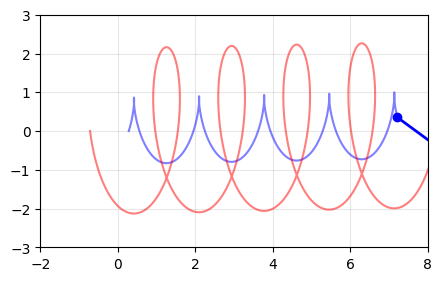

In [92]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

fig, ax = plt.subplots(figsize=(5,5))
ax.set_aspect('equal')
ax.set_xlim(-2, 8)
ax.set_ylim(-3, 3)
ax.grid(alpha=0.3)

line, = ax.plot([], [], 'o-', color='blue', lw=2)
p1, = ax.plot([], [], 'blue', ms=8)
p2, = ax.plot([], [], 'red', ms=8)

trail1, = ax.plot([], [], '-', color='blue', lw=1.5, alpha=0.5)
trail2, = ax.plot([], [], '-', color='red', lw=1.5, alpha=0.5)

def init():
    line.set_data([], [])
    p1.set_data([], [])
    p2.set_data([], [])
    trail1.set_data([], [])
    trail2.set_data([], [])
    return line, p1, p2, trail1, trail2

def update(i):
    idx = frame_indices[i]
    x1, y1 = r1_vals[idx]
    x2, y2 = r2_vals[idx]

    start = 0
    trail1.set_data(r1_vals[start:idx, 0], r1_vals[start:idx, 1])
    trail2.set_data(r2_vals[start:idx, 0], r2_vals[start:idx, 1])

    line.set_data([x1, x2], [y1, y2])
    p1.set_data([x1], [y1])
    p2.set_data([x2], [y2])

    return line, p1, p2, trail1, trail2

ani = FuncAnimation(fig, update, frames=len(frame_indices),
                    init_func=init, interval=1000/animation_fps, blit=True)

# last frame - fast preview
update(len(frame_indices) - 1);

In [93]:
# # uncomment to play video in notebook
# %matplotlib inline
# HTML(ani.to_html5_video())